## **Ablowitz-Ladik Model Learned by SREINet**


## **I. Setup and Preprocessing**


In [1]:
# Import os library to access environment variables and operating system functionalities
import os

# Set environment variable to avoid duplicate library errors, specifically for OpenMP
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
# Set TensorFlow log level to '2' to suppress most messages except warnings and errors
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import sys
sys.path.append("../utilities")

# Import necessary libraries for deep learning and numerical computation
import tensorflow as tf
import numpy as np
from SREINet import * 
import DataGenerator as DG

# Print a formatted message to the terminal to display current time, date, and TensorFlow version
print("**********************************************")
print("*                                            *")
print("*    Tensorflow Version: " + tf.__version__ + "              *")
print("*                                            *")
print("**********************************************")

from packaging import version
if version.parse(tf.__version__) < version.parse('2.10.0') and version.parse(tf.__version__) > version.parse('2.15.0'):
    print("Error: Tensorflow version is lower than 2.10.0 or higher than 2.15.0. Please use Tensorflow 2.10.0 - 2.15.0")
    sys.exit()

MY_DATA_TYPE = 'float32'
# Set the desired data type
tf.keras.backend.set_floatx(MY_DATA_TYPE)  


**********************************************
*                                            *
*    Tensorflow Version: 2.15.0              *
*                                            *
**********************************************


### **1.2 Training Data**

#### Create dataset

Guess highest order polynomial: 3
(200000, 64)


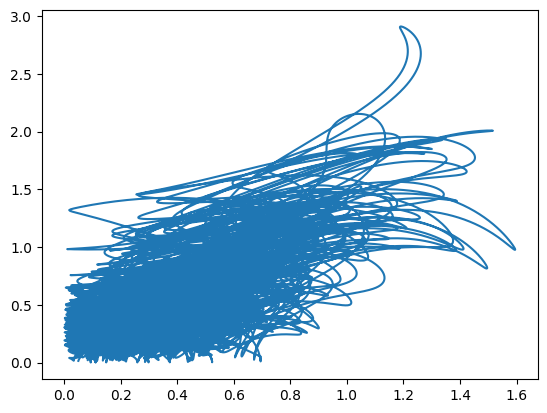

Training input shape: (200000, 128)
Training output shape: (200000, 128)


In [2]:
# Specify the model type
MY_MODEL = 'abolowitz_ladik'  

SEED = 42  # set seed for random number generation
np.random.seed(SEED)

# Generate data based on the specified model type
node_num = 64
node_index = np.linspace(-node_num/2, node_num/2, node_num)

num_traj = 4
data_initial_conditions= []

for i in range(num_traj):
     #trajectory shape 1
        amp = np.random.normal(0, 0.5, node_num)
        phase = np.random.uniform(0, 2*np.pi, node_num)
        new_IC = amp*np.cos(phase) + 1j*amp*np.sin(phase)
        data_initial_conditions.append(new_IC)
        

data_T =  500.0       # Length of the data (T)
data_dt = 0.01       # Resolution of the data (dt)
myDG = DG.DataGenerator(data_initial_conditions,T=data_T, dt=data_dt, random_state=SEED)
t_arr, x_train, dx_train, guess_highest_order_polynomial = myDG.generate_dataset_by_model_name(MY_MODEL, node_num, method="BDF")

print("Guess highest order polynomial:", guess_highest_order_polynomial)

import matplotlib.pyplot as plt
print(x_train.shape)
plt.plot(np.abs(x_train[:,0]), np.abs(dx_train[:,0]))
plt.show()

x_train = np.concatenate((np.real(x_train), np.imag(x_train)), axis=1)
dx_train = np.concatenate((np.real(dx_train), np.imag(dx_train)), axis=1)
training_input, training_output = x_train, dx_train

#data will be shuffled in the fit function

print("Training input shape:", training_input.shape)
print("Training output shape:", training_output.shape)

### **1.3 Hyperparameters**


In [3]:
# Set mini-batch size
MINI_BATCH_SIZE = 512
learning_rate = 0.001

### **1.4 Model Architecture Definitions**


**SREINet Parameters**

In [4]:
#dim is the shape of the 2nd dimension of data; the first dimension is the number of data points
dim = training_input.shape[1] 

layer_depth = guess_highest_order_polynomial
layer_neuron_nums_per_act_fn = [dim] * layer_depth
print(layer_neuron_nums_per_act_fn) # excluding the constant term; NOT the total number of neurons per layer

[128, 128, 128]


## **II. Model Training and Execution**

### **2.1 Create the SREINet Model**


In [5]:
activation_fns = [lambda x:x] #add activation functions here

inputs = tf.keras.layers.Input(shape=(dim,), dtype=MY_DATA_TYPE)
model = SREINet(layer_neuron_nums_per_act_fn, 
                     activations=activation_fns,
                     data_type=MY_DATA_TYPE,
                     weight_initializer=tf.initializers.RandomNormal(stddev=1e-4, seed=SEED),
                     name='SREINet')
output = model(inputs)
model = tf.keras.Model(inputs=inputs, outputs=output)

### **2.2 Loss Function**

In [6]:
LOSS_FUNCTION = 'mse' #This can be 'MSE', 'LASSO', or 'RIDGE' or 'ElasticNet'(case insensitive)

from loss import *

# Example of selecting a loss function
loss_fn = myLoss(model, LOSS_FUNCTION) 

### **2.3 Optimizer**

In [7]:
my_optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)  # Create an Adam optimizer with the defined learning rate

### **2.4 Trainer**


In [8]:
from sreinet_trainer import *

trainer = SREINetTrainer(model, my_optimizer, loss_fn, data_type='float32')

## **III.Training the Model**


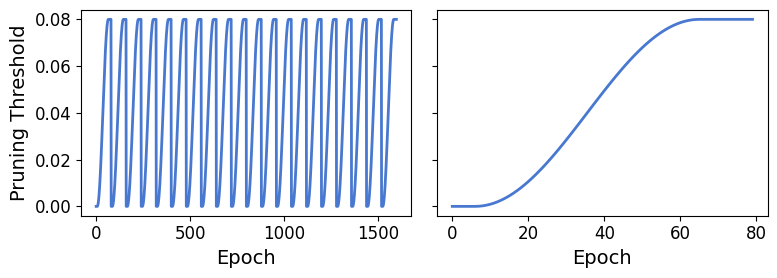

In [9]:
MAX_WEIGHT_PRUNING_THRESHOLD = 0.08
N_PERIODS = 20
PRUNING_EPOCHS_PER_PERIOD = 80
NUM_EPOCHS = PRUNING_EPOCHS_PER_PERIOD * N_PERIODS

import pruning_scheduler as ps

pruning_scheduler = ps.PruningScheduler(steps_per_period=PRUNING_EPOCHS_PER_PERIOD, 
                    num_periods=N_PERIODS,
                    maximum_threshold=MAX_WEIGHT_PRUNING_THRESHOLD,
                    zero_percentage=0.08,
                    show_plot=True)



In [10]:
EARLY_STOPPING_LOSS_THRESHOLD = 1e-10   # Threshold for early stopping (Layer Based)
EARLY_STOPPING_PRUNING_THRESHOLD = 0.03 # Threshold for early stopping (Pruning Based)

training_histories = []
weights_list = []
loss_list = []
print(f"Total Dimensions: {training_output.shape[1]}")
for i in range(training_output.shape[1]):
    print(f"Training dimension {i + 1}...")
    
    output = training_output[:, i:i+1]
    
    history = trainer.fit(training_input, output,
     batch_size=MINI_BATCH_SIZE, 
     validation_split=0.20,
     epochs=round(NUM_EPOCHS), 
     pruning_scheduler=pruning_scheduler,
     early_stopping_loss_threshold=EARLY_STOPPING_LOSS_THRESHOLD,
     early_stopping_pruning_threshold=EARLY_STOPPING_PRUNING_THRESHOLD,
     verbose=1,
    )
    training_histories.append(history)

    # Retrieve the weights of the trained model
    weights_list.append([trainer.get_best_weights()])
    loss_list.append(trainer.get_best_loss())

    #reset the model and trainer
    trainer.reset_trainer_and_model_weights(i)

Total Dimensions: 128
Training dimension 1...
Epoch   1 (Period 1):  Train Loss: 4.260e-02,  Validation Loss: 6.747e-02,  Epoch Time: 1.69s,  Current Pruning Threshold: 0
Epoch   2 (Period 1):  Train Loss: 2.777e-03,  Validation Loss: 6.254e-02,  Epoch Time: 0.97s,  Current Pruning Threshold: 0
Epoch   3 (Period 1):  Train Loss: 4.766e-04,  Validation Loss: 6.042e-02,  Epoch Time: 0.91s,  Current Pruning Threshold: 0
Epoch   4 (Period 1):  Train Loss: 2.428e-04,  Validation Loss: 6.173e-02,  Epoch Time: 0.85s,  Current Pruning Threshold: 0
Epoch   5 (Period 1):  Train Loss: 1.840e-04,  Validation Loss: 5.971e-02,  Epoch Time: 0.95s,  Current Pruning Threshold: 0
Epoch   6 (Period 1):  Train Loss: 2.273e-04,  Validation Loss: 6.138e-02,  Epoch Time: 1.20s,  Current Pruning Threshold: 0
Epoch   7 (Period 1):  Train Loss: 2.427e-04,  Validation Loss: 5.967e-02,  Epoch Time: 0.97s,  Current Pruning Threshold: 0
Epoch   8 (Period 1):  Train Loss: 3.549e-04,  Validation Loss: 6.007e-02,  Epo

## **IV. Coefficient Reconstructor (SREINet)**

#### `generate_set_labels`

The functions below generate labels for the LHS and RHS of governing equations.

In [13]:
def generate_layer_labels(N):
    N = int(N/2)
    return ['Constant'] + [f'a{i}' for i in range(1, N+1)] + [f'b{i}' for i in range(1, N+1)]
def generate_LHS_labels(N):
    N = int(N/2)
    return [f"(a{i})'" for i in range(1, N+1)] + [f"(b{i})'" for i in range(1, N+1)]

#### `coefficient_reconstructor`

In [14]:
from coefficient_reconstructor import *
cr = CoefficientReconstructor(generate_layer_labels, generate_LHS_labels)

## **V. Results**
### **Identified Model**

In [15]:
eq_str = []
for i in range(len(weights_list)):
    path_products = cr.reconstruct_coefficients(i,
                                               weights_list[i], 
                                            minimum_coefficient_threshold = 1e-3,
                                            coefficient_output_digits = 10, 
                                            enable_coefficient_sorting = False)
    
    for index, dimension in enumerate(path_products):
        print(f"{dimension}")
        eq_str.append(dimension)

(a1)' = 0.9999999437*b1 - 0.499999981*a1^2*b2 - 0.499999981*a1^2*b64 - 0.5000000257*b1^2*b2 - 0.4999999968*b1^2*b64 - 0.4999999811*b2 - 0.4999999811*b64
(a2)' =  - 0.5000000154*b1 + 1.000000009*b2 - 0.5000000154*b3 - 0.5000000416*a2^2*b1 - 0.4999999888*b1*b2^2 - 0.4999999888*b2^2*b3 - 0.5000000042*a2^2*b3
(a3)' =  - 0.4999999737*b2 + 1.000000046*b3 - 0.4999998745*b4 - 0.5000001308*a3^2*b2 - 0.4999999109*a3^2*b4 - 0.4999995341*b2*b3^2 - 0.500000962*b3^2*b4
(a4)' =  - 0.4999999584*b3 + 1.00000001*b4 - 0.5000000115*b5 - 0.4999999844*a4^2*b3 - 0.4999999409*a4^2*b5 - 0.5000000678*b3*b4^2 - 0.499999969*b4^2*b5
(a5)' =  - 0.4999999982*b4 - 0.5000000092*a5^2*b4 + 0.9999999963*b5 - 0.4999999828*b4*b5^2 - 0.5000000664*b5^2*b6 - 0.4999999982*b6 - 0.4999998846*a5^2*b6
(a6)' =  - 0.4999999984*a6^2*b5 - 0.4999999984*a6^2*b7 - 0.5000000115*b5 + 1.000000023*b6 - 0.4999999654*b5*b6^2 - 0.4999999774*b6^2*b7 - 0.5000000115*b7
(a7)' =  - 0.4999999434*b6 + 1.000000015*b7 - 0.499999996*b8 - 0.4999999019*a7^

### **Validation**

In [21]:
import model_reconstructor as mr

recovered_model = mr.RecoveredModel()
recovered_model.parse_ode_equations(eq_str);

### Comparing vector field

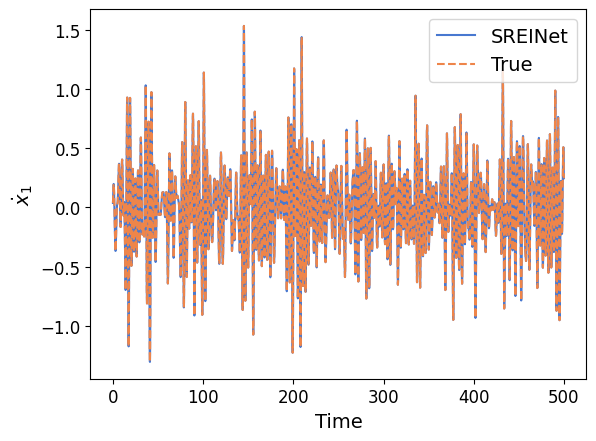

In [23]:
pred_x_dot = recovered_model.predict_derivatives(x_train)

val_t_span = [0,data_T]
val_t_eval = np.arange(0,data_T,data_dt)

import matplotlib.pyplot as plt

plt.plot(val_t_eval, pred_x_dot[:val_t_eval.shape[0], 0],label='SREINet')
plt.plot(val_t_eval, dx_train[:val_t_eval.shape[0],0], '--', label='True')
plt.xlabel('Time')
plt.ylabel(r'$\dot{x}_1$')
plt.legend()
plt.show()


### Comparing response

In [24]:
val_t_span = [0,data_T]
val_t_eval = np.arange(0,data_T,data_dt)

ic = recovered_model.split_complex_initial_conditions(data_initial_conditions[0])

validation_result = recovered_model.simulate(ic, t_span=val_t_span,t_eval=val_t_eval, method='DOP853')

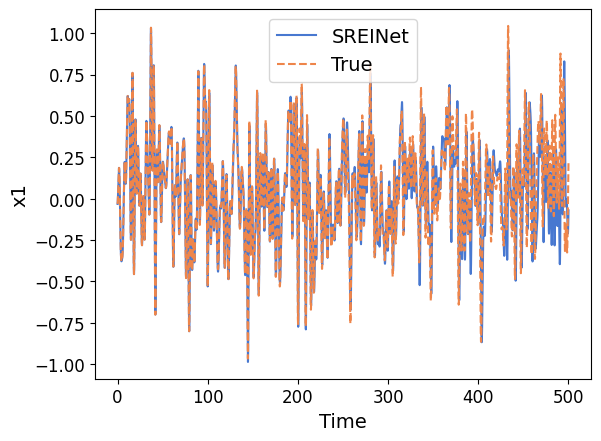

In [25]:
import matplotlib.pyplot as plt

plt.plot(validation_result['t'], validation_result['y'][0],label='SREINet')
plt.plot(val_t_eval, x_train[:val_t_eval.shape[0],0], '--', label='True')
plt.xlabel('Time')
plt.ylabel('x1')
plt.legend()
plt.show()

In [28]:
score =recovered_model.score(x_train[:val_t_eval.shape[0]], dx_train[:val_t_eval.shape[0]])
print(f"Score: {score}")

complexity = recovered_model.calculate_complexity()
print(f"Complexity: {complexity}") # number of nonzero terms 

complexity_per_dimension = complexity / dim
print(f"Complexity per dimension: {complexity_per_dimension}")

Score: 0.9999999999996115
Complexity: 896
Complexity per dimension: 7.0


## **VI. Output**

In [29]:
#save hyperparameters
import pandas as pd

df = pd.DataFrame({
    'ODE model': [MY_MODEL],
    'data initial conditions': [data_initial_conditions],
    'data length (T)': [data_T],
    'data resolution (dt)': [data_dt],
    'learning rate': [learning_rate],
    'layer depth': [layer_depth],
    'input dimension': [x_train.shape[1]],
    'mini_batch_size': [MINI_BATCH_SIZE],
    'Layer Neurons per activation fns': [layer_neuron_nums_per_act_fn],
    'Data Points': [training_input.shape[0]],
    'Total Training Epochs': [NUM_EPOCHS],
    'loss function': [LOSS_FUNCTION],
    'Best loss values': [str(loss_list)], 
    'max weight threshold for pruning': [MAX_WEIGHT_PRUNING_THRESHOLD],
    'loss threshold for early stopping': [EARLY_STOPPING_LOSS_THRESHOLD],
    'pruning epochs per period': [PRUNING_EPOCHS_PER_PERIOD],
    'number of training periods': [N_PERIODS],
})

In [30]:
# Import the output helper module
import output_helper as opt_helper

# Save all results to Excel using the helper function
filepath = opt_helper.save_sreinet_results_to_excel(
    config_df=df,
    training_histories=training_histories,
    recovered_model=recovered_model,
    filename='AL_nn_configurations.xlsx',
    output_dir='output'
)

Successfully saved SREINet results to: output/AL_nn_configurations.xlsx
